In [14]:
import pandas as pd

# 1. Load the high-performance Parquet file
data_path = '../data/raw/simulated_transactions.parquet'
df = pd.read_parquet(data_path)

# 2. Basic observability
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print("-" * 30)

# 3. Schema Check
print("Data Schema:")
print(df.dtypes)
print("-" * 30)

# 4. Class Imbalance Check (Crucial for Fraud)
fraud_count = df['TX_FRAUD'].sum()
fraud_ratio = df['TX_FRAUD'].mean() * 100

print(f"Total Fraudulent Transactions: {fraud_count:,}")
print(f"Fraud Ratio: {fraud_ratio:.4f}%")
print("-" * 30)

# 5. Visual Check
display(df.head())

Total Rows: 1,437,958
Total Columns: 9
------------------------------
Data Schema:
TRANSACTION_ID                int64
TX_DATETIME          datetime64[ns]
CUSTOMER_ID                   int64
TERMINAL_ID                   int64
TX_AMOUNT                   float64
TX_TIME_SECONDS               int64
TX_TIME_DAYS                  int64
TX_FRAUD                      int64
TX_FRAUD_SCENARIO             int64
dtype: object
------------------------------
Total Fraudulent Transactions: 11,857
Fraud Ratio: 0.8246%
------------------------------


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


In [15]:
# Unique values for each column
print("TX_TIME_DAYS unique values:")
print(sorted(df["TX_TIME_DAYS"].dropna().unique()))

print("\nTX_FRAUD unique values:")
print(sorted(df["TX_FRAUD"].dropna().unique()))

print("\nTX_FRAUD_SCENARIO unique values:")
print(sorted(df["TX_FRAUD_SCENARIO"].dropna().unique()))

TX_TIME_DAYS unique values:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149]

TX_FRAUD unique values:
[0, 1]

TX_FRAUD_SCENARIO unique values:
[0, 1, 2, 3]


In [16]:
for col in ["TX_TIME_DAYS", "TX_FRAUD", "TX_FRAUD_SCENARIO"]:
    print(f"\n=== {col} ===")
    print("nunique:", df[col].nunique(dropna=True))
    print(df[col].value_counts(dropna=False).sort_index())


=== TX_TIME_DAYS ===
nunique: 150
TX_TIME_DAYS
0      9488
1      9583
2      9747
3      9530
4      9651
       ... 
145    9607
146    9499
147    9728
148    9597
149    9622
Name: count, Length: 150, dtype: int64

=== TX_FRAUD ===
nunique: 2
TX_FRAUD
0    1426101
1      11857
Name: count, dtype: int64

=== TX_FRAUD_SCENARIO ===
nunique: 4
TX_FRAUD_SCENARIO
0    1426101
1        816
2       7255
3       3786
Name: count, dtype: int64


In [17]:
print(df.columns.tolist())

['TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD', 'TX_FRAUD_SCENARIO']


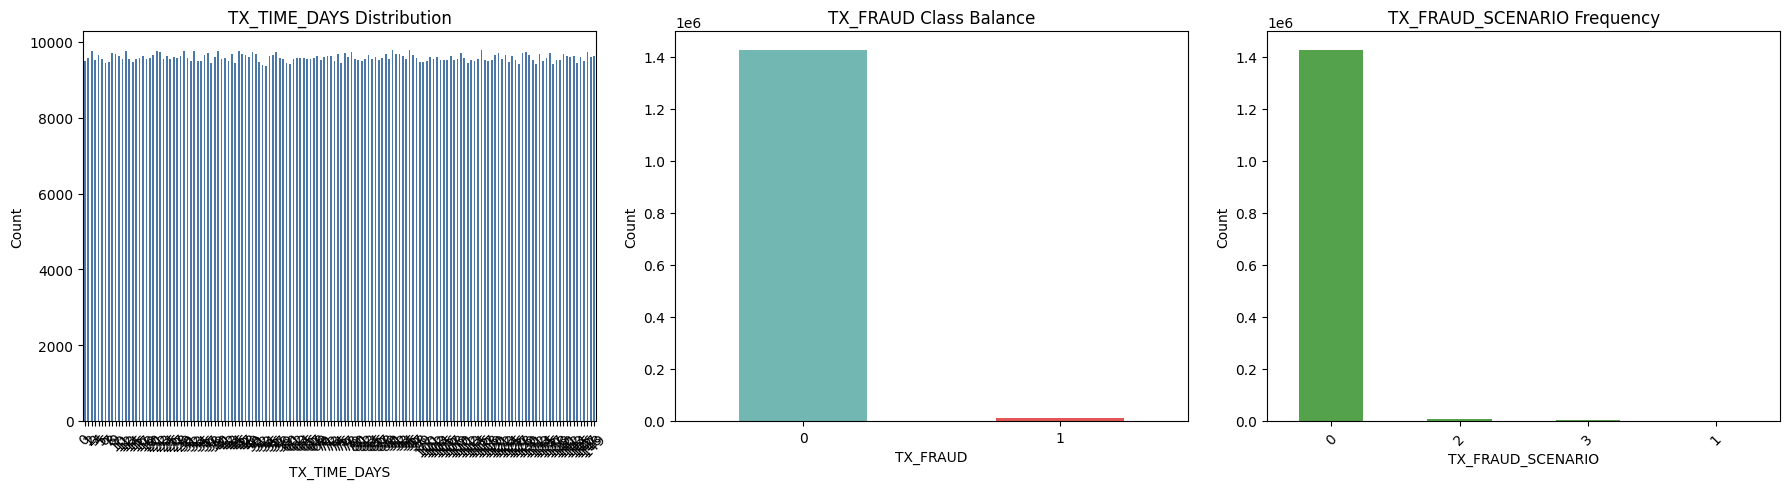

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TX_TIME_DAYS distribution
df["TX_TIME_DAYS"].value_counts(dropna=False).sort_index().plot(
    kind="bar", ax=axes[0], color="#4C78A8"
)
axes[0].set_title("TX_TIME_DAYS Distribution")
axes[0].set_xlabel("TX_TIME_DAYS")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# TX_FRAUD balance
df["TX_FRAUD"].value_counts(dropna=False).sort_index().plot(
    kind="bar", ax=axes[1], color=["#72B7B2", "#E45756"]
)
axes[1].set_title("TX_FRAUD Class Balance")
axes[1].set_xlabel("TX_FRAUD")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

# TX_FRAUD_SCENARIO frequency
df["TX_FRAUD_SCENARIO"].fillna("Missing").astype(str).value_counts().plot(
    kind="bar", ax=axes[2], color="#54A24B"
)
axes[2].set_title("TX_FRAUD_SCENARIO Frequency")
axes[2].set_xlabel("TX_FRAUD_SCENARIO")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()